# Предсказание выхода из строя жёстких дисков

## О проекте

Цель работы — построить модель, которая по ежедневным показателям S.M.A.R.T. предсказывает отказ жёсткого диска за несколько дней до того, как он произойдёт. Это позволяет заранее спланировать замену диска и избежать незапланированных простоев.

## Что внутри

Блокнот состоит из трёх основных частей:

**1. Анализ данных (EDA)**
Cтруктура датасета: сколько дисков, за какой период собраны данные, как часто происходят отказы, выбираем наиболее подходящую модель жесткого диска для предсказания. На этом этапе выявляем ключевые сигналы в данных и проверяем, достаточно ли информации для построения модели.

**2. Подготовка датасета к обучению**
Готовим данные для обучения. Создаём целевую переменную с горизонтом предсказания 7 дней — модель должна ответить на вопрос «сломается ли этот диск в ближайшую неделю». Из 11 сырых S.M.A.R.T.-атрибутов формируем расширенный набор признаков: скользящие статистики, дельты, бинарные флаги. Разбиваем данные на обучающую и тестовую выборки по времени, чтобы избежать утечки информации из будущего.

**3. Выбор baseline-модели**
Обучаем две модели: Gradient Boosting и Random Forest. Сравниваем их на тестовой выборке. В качестве основных метрик используем AUC-PR и F1-score, поскольку данные сильно несбалансированы. Выбираем лучшую модель.

# Data

## Libs

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob

## Load Data

In [2]:
script_dir = os.path.dirname('dataset_preparation.ipynb')

In [3]:
folders_list = os.listdir(os.path.join(script_dir, '..', 'example_raw_data'))
folders_list.sort()
folders_list

['.DS_Store', 'data_Q1_2025', 'data_Q2_2025', 'data_Q3_2025', 'data_Q4_2025']

In [4]:
def load_quarter_data(quarter_folder: str) -> pd.DataFrame:
    quarter_path = os.path.join(script_dir, '..', 'example_raw_data', quarter_folder)
    files = sorted(glob.glob(os.path.join(quarter_path, '*.csv')))
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    return df

In [5]:
q1 = load_quarter_data(folders_list[1])

In [6]:
q1.shape

(27799986, 197)

## Data view

**Note:** [Описание параметров](https://en.wikipedia.org/wiki/Self-Monitoring,_Analysis_and_Reporting_Technology)

**Important features:**

* smart_1 - Read Error Rate
* smart_5 - Reallocated Sectors Count
* smart_10 - Spin Retry Count
* smart_184 - End-to-End error / IOEDC
* smart_187 - Reported Uncorrectable Errors
* smart_188 - Command Timeout
* smart_196 - Reallocation Event Count
* smart_197 - Current Pending Sector Count
* smart_198 - (Offline) Uncorrectable Sector Count
* smart_201 - Soft Read Error Rate or TA Counter Detected

In [7]:
q1.head()

,date,serial_number,model,capacity_bytes,failure,datacenter,cluster_id,vault_id,pod_id,pod_slot_num,...,smart_250_normalized,smart_250_raw,smart_251_normalized,smart_251_raw,smart_252_normalized,smart_252_raw,smart_254_normalized,smart_254_raw,smart_255_normalized,smart_255_raw
0,2025-01-01,2207E60CC65A,CT250MX500SSD1,250059350016,0,sac0,0,1028,13,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,2340E87B92B5,CT250MX500SSD1,250059350016,0,sac0,0,1028,14,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01,2EGK64VX,HGST HUH728080ALE604,8001563222016,0,sac0,0,1028,4,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-01,2EHZAKAX,HGST HUH728080ALE604,8001563222016,0,sac0,0,1028,12,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-01,2EJ02A1X,HGST HUH728080ALE604,8001563222016,0,sac0,0,1028,10,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
q1.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 27799986 entries, 0 to 27799985
Data columns (total 197 columns):
 #    Column                Dtype  
---   ------                -----  
 0    date                  str    
 1    serial_number         str    
 2    model                 str    
 3    capacity_bytes        int64  
 4    failure               int64  
 5    datacenter            str    
 6    cluster_id            int64  
 7    vault_id              int64  
 8    pod_id                int64  
 9    pod_slot_num          float64
 10   is_legacy_format      bool   
 11   smart_1_normalized    float64
 12   smart_1_raw           float64
 13   smart_2_normalized    float64
 14   smart_2_raw           float64
 15   smart_3_normalized    float64
 16   smart_3_raw           float64
 17   smart_4_normalized    float64
 18   smart_4_raw           float64
 19   smart_5_normalized    float64
 20   smart_5_raw           float64
 21   smart_7_normalized    float64
 22   smart_7_raw           flo

Удалим пустые столбцы

In [9]:
q1_cleaned = q1.dropna(axis=1, how='all')

In [10]:
q1_cleaned.shape

(27799986, 175)

In [11]:
q1_cleaned.describe(include='all')

,date,serial_number,model,capacity_bytes,failure,datacenter,cluster_id,vault_id,pod_id,pod_slot_num,...,smart_245_normalized,smart_245_raw,smart_246_normalized,smart_246_raw,smart_247_normalized,smart_247_raw,smart_248_normalized,smart_248_raw,smart_254_normalized,smart_254_raw
count,27799986,27799986,27799986,2.779999e+07,2.779999e+07,27799986,2.779999e+07,2.779999e+07,2.779999e+07,2.742199e+07,...,8014.000000,8014.000000,63474.0,6.347400e+04,63474.0,6.347400e+04,63474.0,6.347400e+04,18751.000000,18751.0
unique,90,318426,76,NaN,NaN,6,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2025-03-09,2207E60CC65A,TOSHIBA MG08ACA16TA,NaN,NaN,phx1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,313676,90,3616128,NaN,NaN,8933177,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,1.461750e+13,3.838131e-05,NaN,1.427284e+01,1.388021e+03,9.499897e+00,2.864440e+01,...,85.970302,85.970302,100.0,1.163865e+11,100.0,2.018174e+09,100.0,3.441826e+09,103.359821,0.0
std,NaN,NaN,NaN,4.087256e+12,6.195147e-03,NaN,1.994277e+01,5.325862e+02,5.766344e+00,1.732502e+01,...,14.358850,14.358850,0.0,1.010576e+11,0.0,3.176027e+09,0.0,5.161828e+09,18.019739,0.0
min,NaN,NaN,NaN,2.400574e+11,0.000000e+00,NaN,0.000000e+00,1.000000e+03,0.000000e+00,0.000000e+00,...,16.000000,16.000000,100.0,1.798550e+07,100.0,1.923060e+05,100.0,1.116000e+04,100.000000,0.0
25%,NaN,NaN,NaN,1.200014e+13,0.000000e+00,NaN,0.000000e+00,1.067000e+03,5.000000e+00,1.400000e+01,...,90.000000,90.000000,100.0,7.578522e+10,100.0,1.107218e+09,100.0,1.182896e+09,100.000000,0.0
50%,NaN,NaN,NaN,1.600090e+13,0.000000e+00,NaN,0.000000e+00,1.131000e+03,9.000000e+00,2.800000e+01,...,91.000000,91.000000,100.0,1.146792e+11,100.0,1.679643e+09,100.0,1.685327e+09,100.000000,0.0
75%,NaN,NaN,NaN,1.600090e+13,0.000000e+00,NaN,3.100000e+01,1.413000e+03,1.500000e+01,4.400000e+01,...,92.000000,92.000000,100.0,1.524101e+11,100.0,2.274920e+09,100.0,3.421129e+09,100.000000,0.0


In [12]:
q1_cleaned.isna().sum()

date                           0
serial_number                  0
model                          0
capacity_bytes                 0
failure                        0
                          ...   
smart_247_raw           27736512
smart_248_normalized    27736512
smart_248_raw           27736512
smart_254_normalized    27781235
smart_254_raw           27781235
Length: 175, dtype: int64

### Вывод

Данные включают такие параметры как дата, серийный номер, модель жесткого диска, расположение жесткого диска, параметры S.M.A.R.T. : сырые и нормализованные. Всего 197 параметров в сумме.
Большая часть данных представлена в формате `float64`.
Параметры S.M.A.R.T. содержат большое количество пропусков.

## Data preparation & analysis

**Note:** Для формирования финального датасета будут выбрана определенная модель жесткого диска.

### To date format

In [13]:
q1_cleaned['date'] = pd.to_datetime(q1_cleaned['date'])

### Целевая переменная

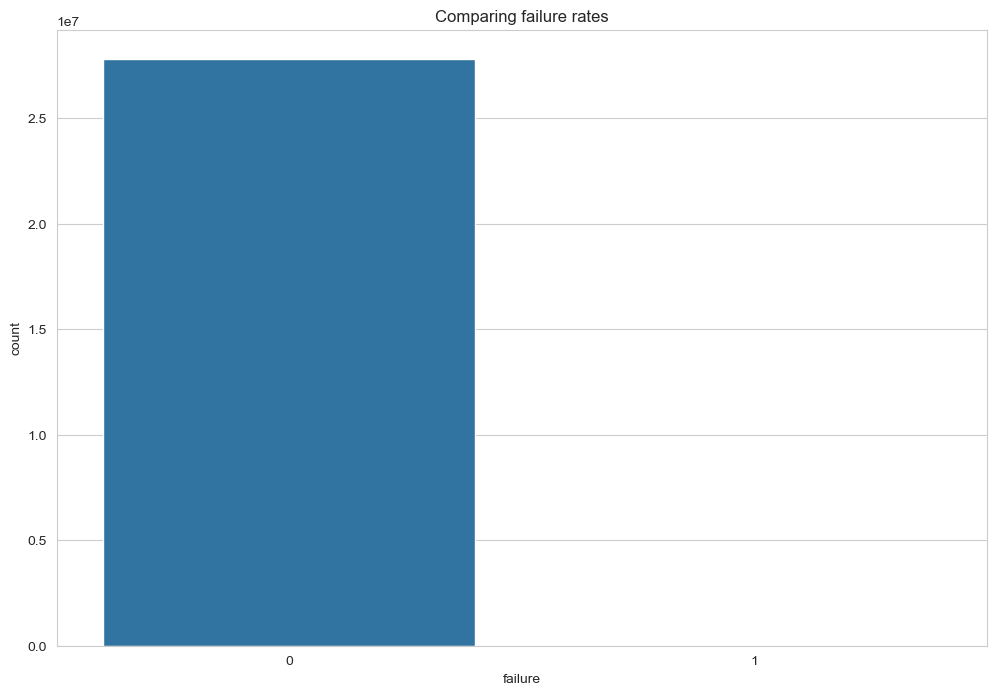

In [14]:
plt.figure(figsize=(12, 8))
sns.countplot(data=q1_cleaned, x='failure')
plt.title('Comparing failure rates')
plt.show()

Процент вышедших из строя жестких дисков

In [15]:
print(f'{q1_cleaned.loc[q1_cleaned['failure'] == 1, 'failure'].sum() / len(q1_cleaned) * 100:.4f}')

0.0038


Присутствует дизбаланс классов. Следует выбирать модели дисков, которые наиболее склонны к выходу из строя.

### Рассмотрение моделей

In [16]:
q1_cleaned['model'].nunique()

76

Наиболее чаще встречающиеся модели

In [17]:
models_nvalue = q1_cleaned['model'].value_counts()

In [18]:
indx = np.argsort(models_nvalue)[::-1][:10]
models_nvalue.iloc[indx]

model
TOSHIBA MG08ACA16TA     3616128
TOSHIBA MG07ACA14TA     3385931
ST16000NM001G           3029485
WDC WUH722222ALE6L4     2870372
WDC WUH721816ALE6L4     2375575
ST12000NM0008           1714395
ST8000NM0055            1212798
HGST HUH721212ALE604    1197864
ST12000NM001G           1186197
ST14000NM001G            951836
Name: count, dtype: int64

Пропуски

In [19]:
q1_cleaned['model'].isna().sum()

np.int64(0)

In [20]:
total_disks_per_model = q1_cleaned.groupby('model')['serial_number'].nunique()
failed_disks_per_model = q1_cleaned[q1_cleaned['failure'] == 1].groupby('model')['serial_number'].nunique()
failure_rate_df = pd.DataFrame({
    'total_disks': total_disks_per_model,
    'failed_disks': failed_disks_per_model
}).fillna(0)
failure_rate_df['failure_rate_%'] = (failure_rate_df['failed_disks'] / failure_rate_df['total_disks']) * 100

In [21]:
failure_rate_df

,total_disks,failed_disks,failure_rate_%
model,,,
CT250MX500SSD1,709,0.0,0.000000
DELLBOSS VD,431,0.0,0.000000
HGST HMS5C4040ALE640,264,0.0,0.000000
HGST HMS5C4040BLE640,4121,3.0,0.072798
HGST HUH721010ALE600,20,0.0,0.000000
...,...,...,...
WDC WUH721414ALE6L4,8615,21.0,0.243761
WDC WUH721816ALE6L0,3016,11.0,0.364721
WDC WUH721816ALE6L4,26428,35.0,0.132435


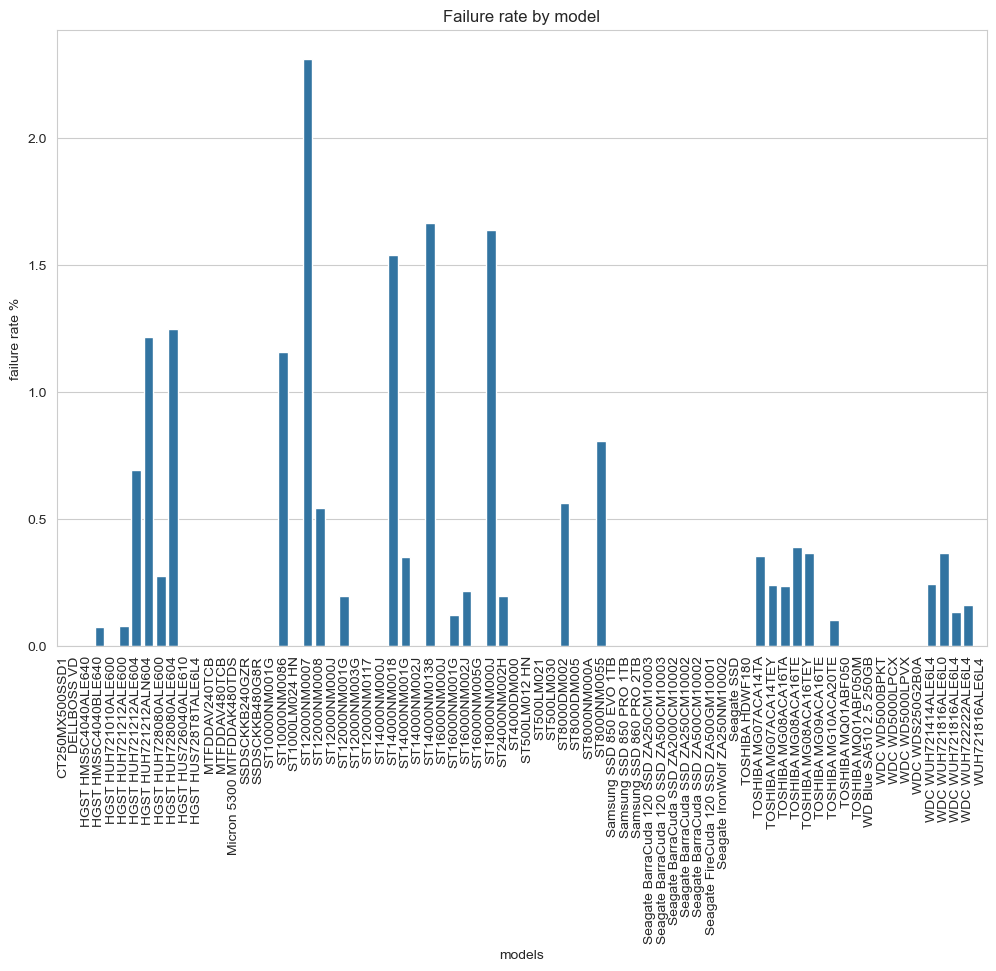

In [22]:
plt.figure(figsize=(12,8))
sns.barplot(data=failure_rate_df, x = 'model',y='failure_rate_%')
plt.title('Failure rate by model')
plt.xlabel('models')
plt.ylabel('failure rate %')
plt.xticks(rotation=90)
plt.show()

Количество дисков с 1% и более соотношением поломок

In [23]:
failure_rate_df[failure_rate_df['failure_rate_%'] >= 1]['total_disks']

model
HGST HUH721212ALN604    10195
HGST HUH728080ALE604       80
ST10000NM0086            1036
ST12000NM0007            1038
ST14000NM0018              65
ST14000NM0138            1322
ST18000NM000J              61
Name: total_disks, dtype: int64

In [24]:
failure_rate_df.loc['HGST HUH721212ALN604']['failure_rate_%']

np.float64(1.2162824914173616)


Для формирования финального датасета выберем модель жесткого диска **"HGST HUH721212ALN604"**. Данная модель обладает относительно высоким процентом отказов, а так же достаточным количеством записей в изначальном датасете.

### capacity bytes

Пропуски

In [25]:
q1_cleaned['capacity_bytes'].isna().sum()

np.int64(0)

In [26]:
q1_cleaned['capacity_bytes'] = q1_cleaned['capacity_bytes'] / np.power(2, 30) # to GB

In [27]:
q1_cleaned['capacity_bytes'].min()

np.float64(223.57088470458984)

In [28]:
q1_cleaned['capacity_bytes'].max()

np.float64(22352.0)

In [29]:
time_mask = q1_cleaned['date'] == '2025-01-01'

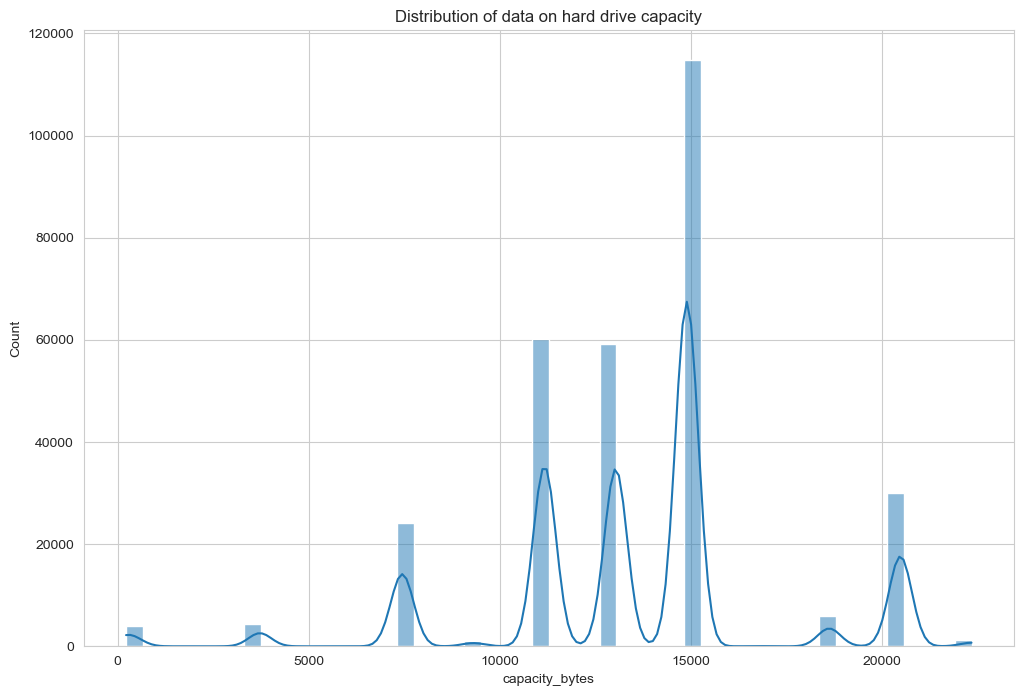

In [30]:
plt.figure(figsize=(12,8))
sns.histplot(data=q1_cleaned[time_mask], x = 'capacity_bytes', bins=50, kde=True)
plt.title('Distribution of data on hard drive capacity')
plt.show()

In [31]:
fail_mask = q1_cleaned['failure'] == 1

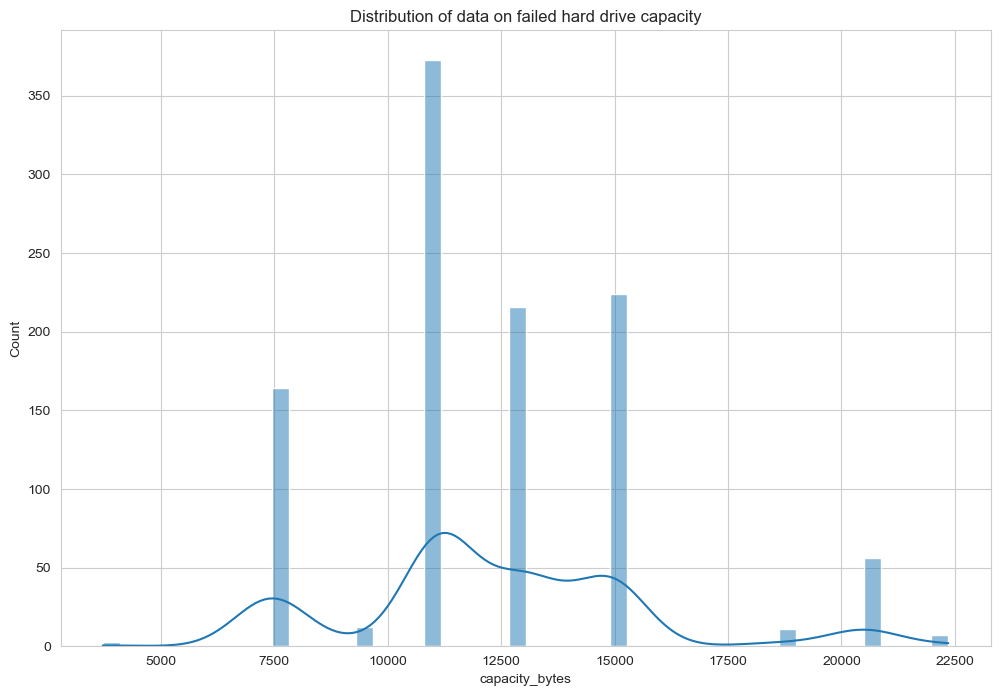

In [32]:
plt.figure(figsize=(12,8))
sns.histplot(data=q1_cleaned[fail_mask], x = 'capacity_bytes', bins=50, kde=True)
plt.title('Distribution of data on failed hard drive capacity')
plt.show()
### Legacy format

Пропуски

In [33]:
q1_cleaned['is_legacy_format'].isna().sum()

np.int64(0)

In [34]:
q1_cleaned['is_legacy_format']

0           False
1           False
2           False
3           False
4           False
            ...  
27799981    False
27799982    False
27799983    False
27799984    False
27799985    False
Name: is_legacy_format, Length: 27799986, dtype: bool

In [35]:
q1_cleaned['is_legacy_format'].nunique()

1

Параметр `is_legacy_formaat` имеет только одно уникальное значение и не представляет полезной информации.

### S.M.A.R.T features

In [36]:
df_HGST = q1_cleaned.loc[q1_cleaned['model'] == 'HGST HUH721212ALN604'].drop(['model', 'capacity_bytes', 'datacenter', 'cluster_id','vault_id', 'pod_id', 'pod_slot_num', 'is_legacy_format'], axis=1)
df_HGST

,date,serial_number,failure,smart_1_normalized,smart_1_raw,smart_2_normalized,smart_2_raw,smart_3_normalized,smart_3_raw,smart_4_normalized,...,smart_245_normalized,smart_245_raw,smart_246_normalized,smart_246_raw,smart_247_normalized,smart_247_raw,smart_248_normalized,smart_248_raw,smart_254_normalized,smart_254_raw
70556,2025-01-01,5PG0P2VF,0,100.0,0.0,130.0,100.0,162.0,406.0,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70893,2025-01-01,8DKHU24H,0,100.0,0.0,132.0,96.0,100.0,0.0,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72092,2025-01-01,8CHRG6JE,0,100.0,0.0,100.0,0.0,164.0,400.0,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72093,2025-01-01,8CHU2WSE,0,100.0,0.0,133.0,92.0,164.0,402.0,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72094,2025-01-01,8CHUNVME,0,100.0,0.0,100.0,0.0,160.0,409.0,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27638392,2025-03-31,5QJGE50B,0,100.0,0.0,132.0,96.0,100.0,0.0,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27638393,2025-03-31,5QKEA6VB,0,100.0,0.0,132.0,96.0,100.0,0.0,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27638394,2025-03-31,5QKHBVPB,0,100.0,0.0,132.0,96.0,100.0,0.0,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27638395,2025-03-31,5QKVA5WB,0,100.0,0.0,130.0,100.0,100.0,0.0,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
columns_hgst = df_HGST.columns

In [38]:
for feat in columns_hgst:
    print(f'{feat}: {df_HGST[feat].isna().sum() / len(df_HGST) * 100:.2f} %')

date: 0.00 %
serial_number: 0.00 %
failure: 0.00 %
smart_1_normalized: 0.00 %
smart_1_raw: 0.00 %
smart_2_normalized: 0.00 %
smart_2_raw: 0.00 %
smart_3_normalized: 0.00 %
smart_3_raw: 0.00 %
smart_4_normalized: 0.00 %
smart_4_raw: 0.00 %
smart_5_normalized: 0.00 %
smart_5_raw: 0.00 %
smart_7_normalized: 0.00 %
smart_7_raw: 0.00 %
smart_8_normalized: 0.00 %
smart_8_raw: 0.00 %
smart_9_normalized: 0.00 %
smart_9_raw: 0.00 %
smart_10_normalized: 0.00 %
smart_10_raw: 0.00 %
smart_11_normalized: 100.00 %
smart_11_raw: 100.00 %
smart_12_normalized: 0.00 %
smart_12_raw: 0.00 %
smart_13_normalized: 100.00 %
smart_13_raw: 100.00 %
smart_16_normalized: 100.00 %
smart_16_raw: 100.00 %
smart_17_normalized: 100.00 %
smart_17_raw: 100.00 %
smart_18_normalized: 100.00 %
smart_18_raw: 100.00 %
smart_22_normalized: 0.00 %
smart_22_raw: 0.00 %
smart_23_normalized: 100.00 %
smart_23_raw: 100.00 %
smart_24_normalized: 100.00 %
smart_24_raw: 100.00 %
smart_27_normalized: 100.00 %
smart_27_raw: 100.00 %
sm

In [39]:
df_HGST.drop(['smart_1_normalized','smart_2_normalized','smart_3_normalized','smart_4_normalized','smart_5_normalized','smart_7_normalized','smart_8_normalized','smart_9_normalized','smart_10_normalized','smart_12_normalized', 'smart_22_normalized','smart_192_normalized','smart_193_normalized','smart_194_normalized','smart_196_normalized','smart_197_normalized','smart_198_normalized','smart_199_normalized','smart_241_normalized','smart_242_normalized'], axis=1, inplace=True)
df_HGST

,date,serial_number,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_8_raw,...,smart_245_normalized,smart_245_raw,smart_246_normalized,smart_246_raw,smart_247_normalized,smart_247_raw,smart_248_normalized,smart_248_raw,smart_254_normalized,smart_254_raw
70556,2025-01-01,5PG0P2VF,0,0.0,100.0,406.0,11.0,0.0,0.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70893,2025-01-01,8DKHU24H,0,0.0,96.0,0.0,9.0,0.0,0.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72092,2025-01-01,8CHRG6JE,0,0.0,0.0,400.0,10.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72093,2025-01-01,8CHU2WSE,0,0.0,92.0,402.0,18.0,0.0,0.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72094,2025-01-01,8CHUNVME,0,0.0,0.0,409.0,14.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27638392,2025-03-31,5QJGE50B,0,0.0,96.0,0.0,3.0,0.0,0.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27638393,2025-03-31,5QKEA6VB,0,0.0,96.0,0.0,4.0,0.0,0.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27638394,2025-03-31,5QKHBVPB,0,0.0,96.0,0.0,1.0,0.0,0.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27638395,2025-03-31,5QKVA5WB,0,0.0,100.0,0.0,2.0,0.0,0.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Удаление пустых столбцов

In [40]:
df_HGST.dropna(axis=1,how='all', inplace=True)

In [41]:
df_HGST.drop(['smart_241_raw', 'smart_242_raw'], axis=1, inplace=True)

In [42]:
col_to_cor = df_HGST.columns
col_to_cor

Index(['date', 'serial_number', 'failure', 'smart_1_raw', 'smart_2_raw',
       'smart_3_raw', 'smart_4_raw', 'smart_5_raw', 'smart_7_raw',
       'smart_8_raw', 'smart_9_raw', 'smart_10_raw', 'smart_12_raw',
       'smart_22_raw', 'smart_192_raw', 'smart_193_raw', 'smart_194_raw',
       'smart_196_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw'],
      dtype='str')

In [43]:
corr_matrix = df_HGST[col_to_cor[2:]].corr()

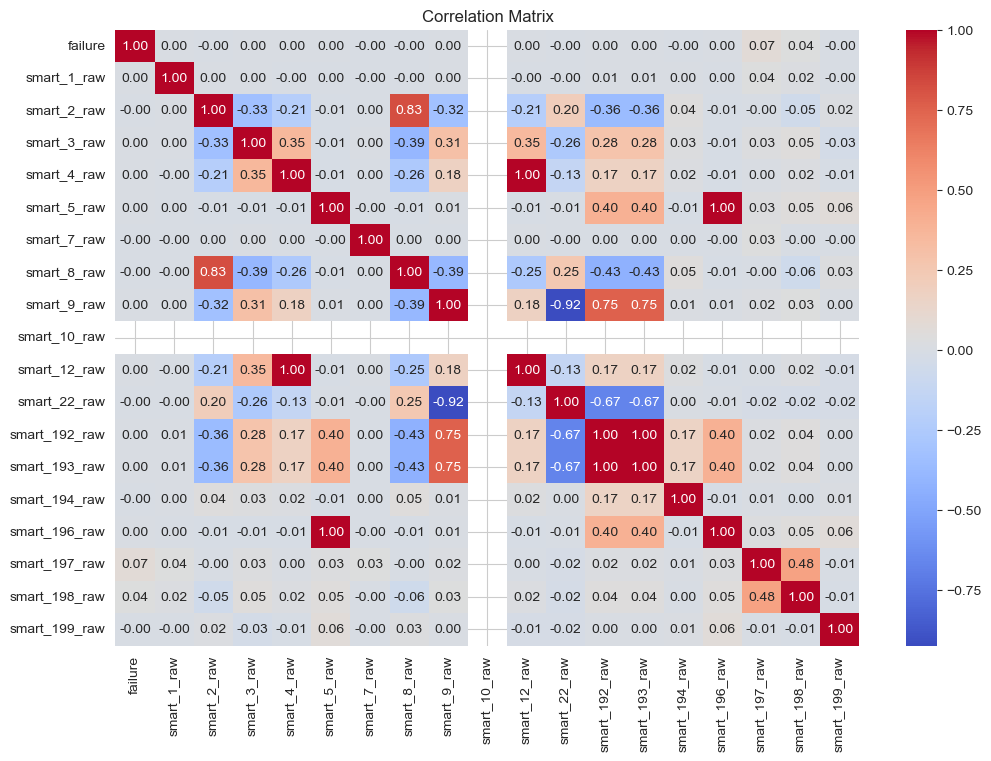

In [44]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Удалим параметры с высокой корреляцией

In [45]:
df_HGST.drop(['smart_4_raw','smart_8_raw','smart_9_raw','smart_10_raw','smart_193_raw','smart_196_raw'], axis=1, inplace=True)

In [46]:
df_HGST

,date,serial_number,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_5_raw,smart_7_raw,smart_12_raw,smart_22_raw,smart_192_raw,smart_194_raw,smart_197_raw,smart_198_raw,smart_199_raw
70556,2025-01-01,5PG0P2VF,0,0.0,100.0,406.0,0.0,0.0,11.0,100.0,1461.0,31.0,0.0,0.0,0.0
70893,2025-01-01,8DKHU24H,0,0.0,96.0,0.0,0.0,0.0,9.0,100.0,1578.0,31.0,0.0,0.0,0.0
72092,2025-01-01,8CHRG6JE,0,0.0,0.0,400.0,0.0,0.0,10.0,100.0,1618.0,27.0,0.0,0.0,0.0
72093,2025-01-01,8CHU2WSE,0,0.0,92.0,402.0,0.0,0.0,18.0,100.0,1424.0,27.0,0.0,0.0,0.0
72094,2025-01-01,8CHUNVME,0,0.0,0.0,409.0,0.0,0.0,14.0,100.0,1698.0,31.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27638392,2025-03-31,5QJGE50B,0,0.0,96.0,0.0,0.0,0.0,3.0,6553700.0,314.0,38.0,0.0,0.0,0.0
27638393,2025-03-31,5QKEA6VB,0,0.0,96.0,0.0,0.0,0.0,4.0,6553700.0,366.0,40.0,0.0,0.0,0.0
27638394,2025-03-31,5QKHBVPB,0,0.0,96.0,0.0,0.0,0.0,1.0,6553700.0,274.0,32.0,0.0,0.0,0.0
27638395,2025-03-31,5QKVA5WB,0,0.0,100.0,0.0,0.0,0.0,2.0,6553700.0,339.0,31.0,0.0,0.0,0.0


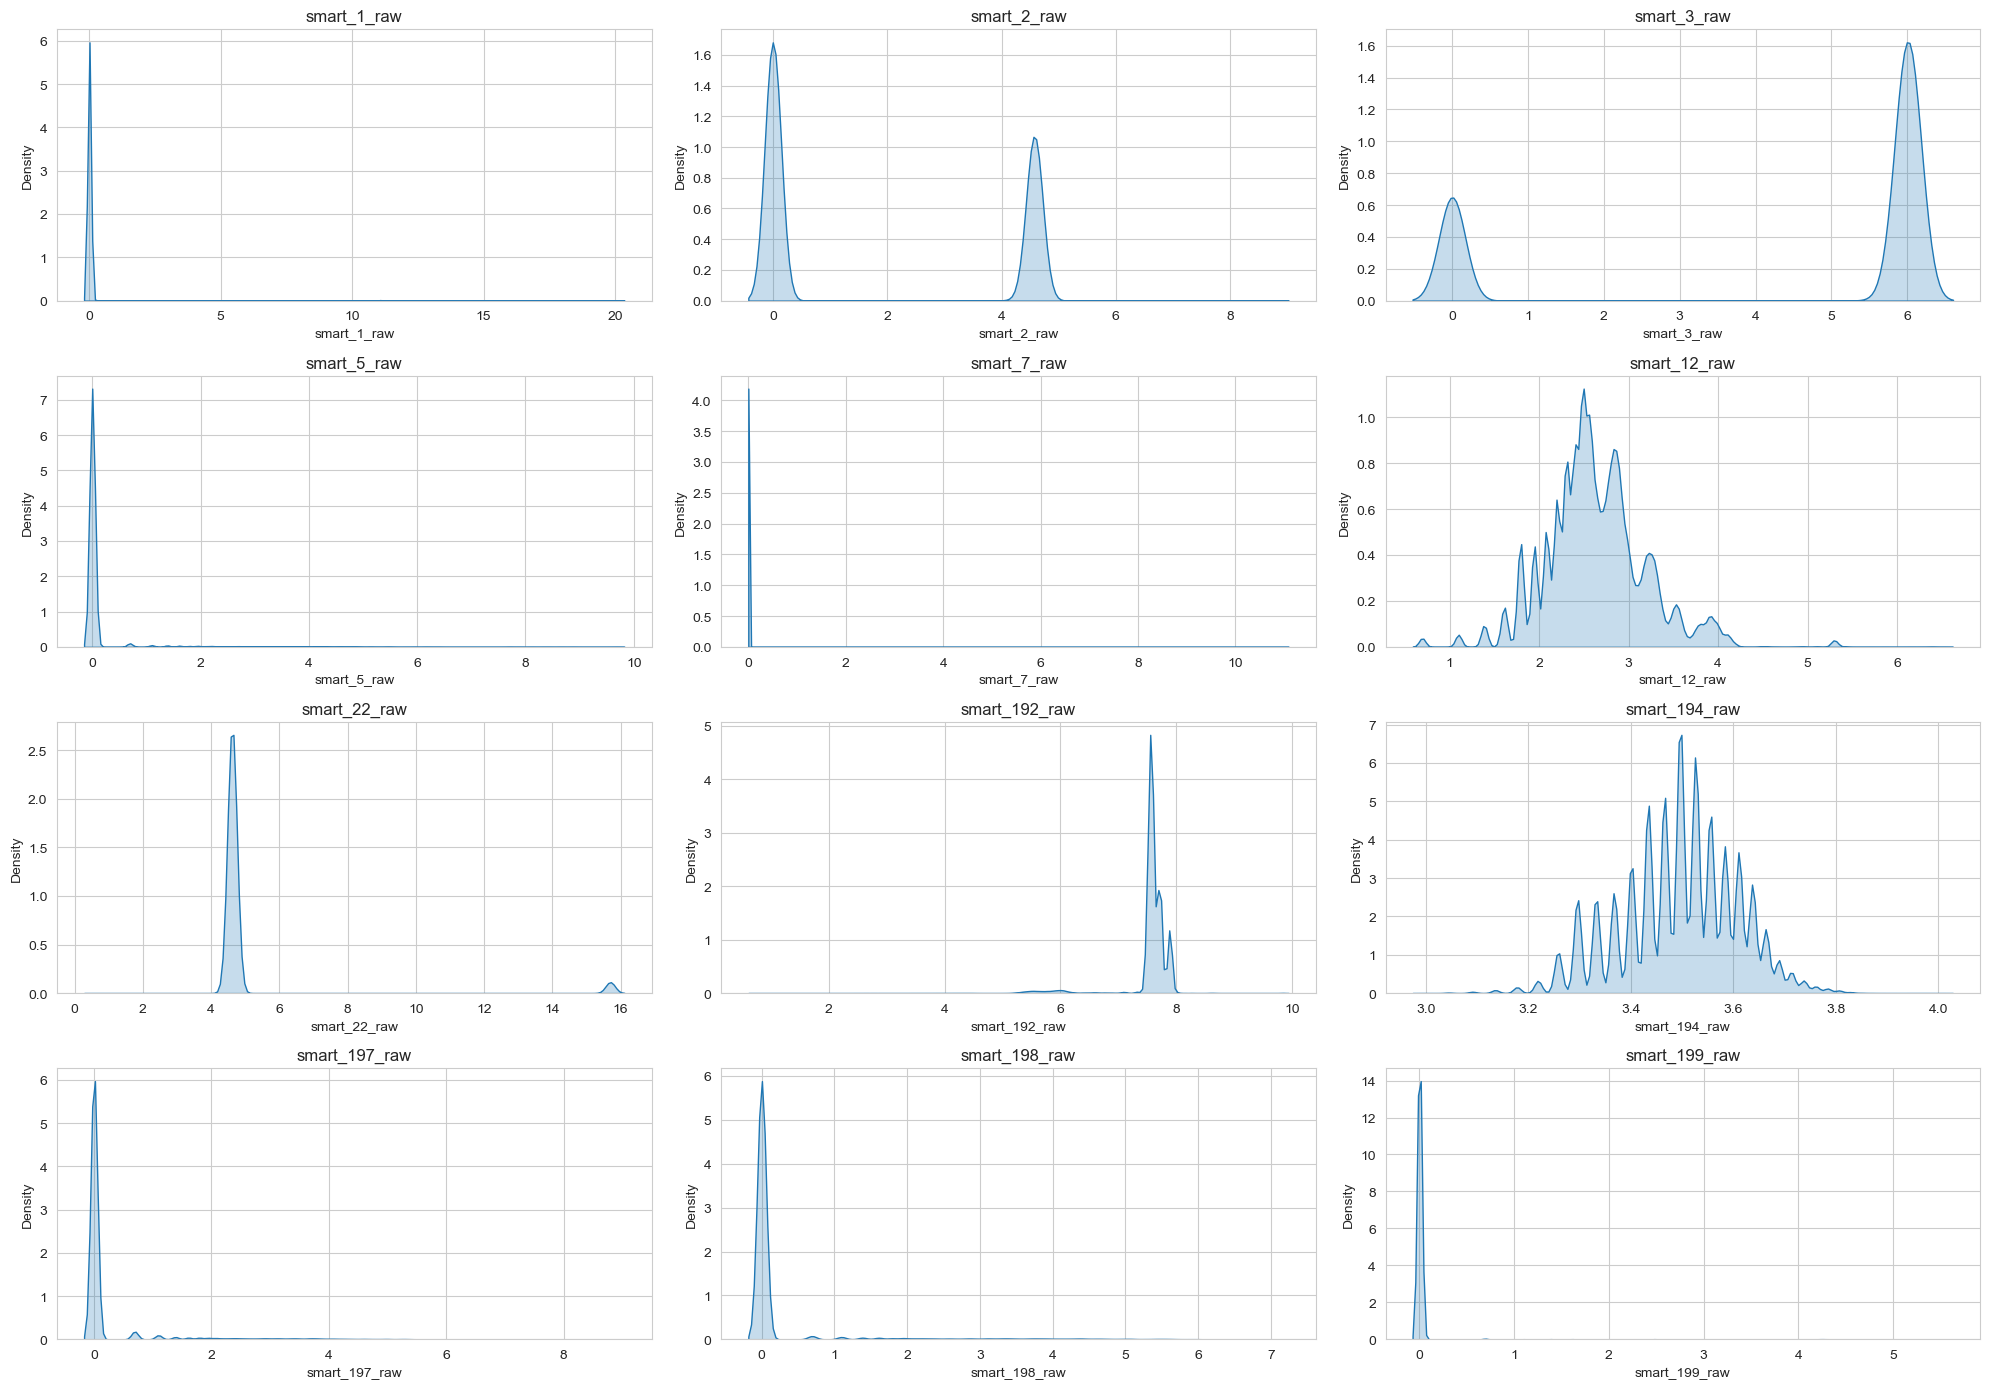

In [47]:
features = df_HGST.columns
fig, axes = plt.subplots(4,3,figsize=(20,14))
axes = axes.flatten()
for i, feature in enumerate(features[3:]):
    ax = axes[i]
    sns.kdeplot(np.log1p(df_HGST[feature]), ax=ax, fill=True)
    ax.set_title(feature)
plt.tight_layout()
plt.show()

In [48]:
df_HGST[features[3:]].nunique()

smart_1_raw      1556
smart_2_raw       109
smart_3_raw       151
smart_5_raw       439
smart_7_raw         3
smart_12_raw      142
smart_22_raw       37
smart_192_raw    3629
smart_194_raw      36
smart_197_raw     587
smart_198_raw     425
smart_199_raw      88
dtype: int64

In [49]:
df_HGST['smart_7_raw'].value_counts()

smart_7_raw
0.0        911542
1.0             2
65536.0         2
Name: count, dtype: int64

In [50]:
df_HGST.drop('smart_7_raw', axis=1, inplace=True)

reducing the dataset

Приведем датасет к размеру 90% -жесткие диски, не вышедшие строя, 10% - жесткие диски, вышедшие из строя

In [60]:
df_HGST[df_HGST['failure'] == 1]['serial_number'].nunique()

124

In [56]:
stable_serial_numbers = df_HGST.loc[(df_HGST['failure'] == 0) & (df_HGST['date'] == '2025-03-31'), 'serial_number'].unique()
stable_serial_numbers

<StringArray>
['5PG0P2VF', '8DKHU24H', '8CHRG6JE', '8CHU2WSE', '8CHUNVME', '8DK8E54H',
 'AAG6E4KH', '5QGGN2GB', '5PJVPN8F', '5QGG4KRB',
 ...
 '5QKV381B', '5QKVDDWB', '5QKYM7MB', '5QHDKVHB', '5QJ77WYB', '5QJGE50B',
 '5QKEA6VB', '5QKHBVPB', '5QKVA5WB', '5QKVGLWB']
Length: 10068, dtype: str

In [88]:
df_prepared = df_HGST[~df_HGST['serial_number'].isin(stable_serial_numbers[1116:])]
df_prepared['serial_number'].nunique()

1243

In [62]:
# df_prepared.to_csv('data.csv', index=False)

## Вывод

В данном разделе был проведен анализ изначального датасета, в ходе которого обнаружилось наличие большого количества пропусков данных, а также дисбаланс данных в целевой переменной.
Для дальнейшего обучения была выбрана модель жесткого диска с достаточным количеством данных положительного целевого параметра.

# Baseline models

Предсказание отказа в ближайшие N дней

## Целевая переменная

In [66]:
prediction_horizon_days = 7

In [89]:
failure_dates = df_prepared[df_prepared['failure'] == 1][['serial_number', 'date']].rename(
    columns={'date': 'failure_date'})

In [90]:
df_prepared = df_prepared.merge(failure_dates, on='serial_number', how='left')

In [91]:
# label=1, если до отказа осталось <= prediction_horizon_days
df_prepared['days_to_failure'] = (df_prepared['failure_date'] - df_prepared['date']).dt.days
df_prepared['label'] = ((df_prepared['days_to_failure'] >= 0) &
                        (df_prepared['days_to_failure'] <= prediction_horizon_days)).astype(int)

In [92]:
df_prepared = df_prepared[df_prepared['failure'] == 0]

Исходная колонка `failure` содержит метку 1 только в день фактического отказа диска. Предсказывать отказ в день, когда он уже произошел, бесполезно.
Мы создаём новую целевую переменную `label`:
- Все записи за 7 дней до отказа помечаем `label = 1`
- Все остальные записи — `label = 0`

## Feature Engineering

In [93]:
rolling_windows = [3, 7, 14]  # окна для скользящих статистик

smart_cols = [
    'smart_1_raw', 'smart_2_raw', 'smart_3_raw', 'smart_5_raw',
    'smart_12_raw', 'smart_22_raw', 'smart_192_raw', 'smart_194_raw',
    'smart_197_raw', 'smart_198_raw', 'smart_199_raw'
]

In [94]:
feature_cols = list(smart_cols)

### Скользящие статистики (окна 3, 7, 14 дней)

Для каждого SMART-атрибута считаем **среднее** и **стандартное отклонение** за последние N дней.

In [95]:
for window in rolling_windows:
    for col in smart_cols:
        rolled = df_prepared.groupby('serial_number')[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        col_name = f"{col}_roll_mean_{window}"
        df_prepared[col_name] = rolled
        feature_cols.append(col_name)

        rolled_std = df_prepared.groupby('serial_number')[col].transform(
            lambda x: x.rolling(window, min_periods=1).std()
        )
        col_name_std = f"{col}_roll_std_{window}"
        df_prepared[col_name_std] = rolled_std.fillna(0)
        feature_cols.append(col_name_std)

### Дельты (изменение за 1 и 3 дня)

Разница между текущим значением и значением 1 или 3 дня назад. Диск с `smart_197 = 100`, который стабильно живёт с этим месяц — это одна ситуация. Диск, у которого вчера было 50, а сегодня 100 — совсем другая. Дельта ловит именно эту разницу.

In [96]:
new_cols = {}
for col in smart_cols:
    for shift in [1, 3]:
        delta = df_prepared.groupby('serial_number')[col].transform(
            lambda x: x.diff(shift)
        )
        new_cols[f"{col}_delta_{shift}d"] = delta.fillna(0)

df = pd.concat([df_prepared, pd.DataFrame(new_cols)], axis=1)

### Бинарные флаги

Для трёх критических атрибутов (`smart_5`, `smart_197`, `smart_198`) создаём признак: есть ли проблема сегодня (0 или 1).

In [97]:
for col in ['smart_5_raw', 'smart_197_raw', 'smart_198_raw']:
    flag_name = f"{col}_nonzero"
    df[flag_name] = (df[col] > 0).astype(int)
    feature_cols.append(flag_name)


### Возраст диска

Сколько дней диск находится в наблюдении.

In [98]:
df['disk_age_days'] = df.groupby('serial_number').cumcount() + 1
feature_cols.append('disk_age_days')

df[feature_cols] = df[feature_cols].fillna(0)

In [113]:
df.head(3)

,date,serial_number,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_5_raw,smart_12_raw,smart_22_raw,smart_192_raw,...,smart_197_raw_delta_1d,smart_197_raw_delta_3d,smart_198_raw_delta_1d,smart_198_raw_delta_3d,smart_199_raw_delta_1d,smart_199_raw_delta_3d,smart_5_raw_nonzero,smart_197_raw_nonzero,smart_198_raw_nonzero,disk_age_days
0,2025-01-01,5PG0P2VF,0,0.0,100.0,406.0,0.0,11.0,100.0,1461.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1
1,2025-01-01,8DKHU24H,0,0.0,96.0,0.0,0.0,9.0,100.0,1578.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1
2,2025-01-01,8CHRG6JE,0,0.0,0.0,400.0,0.0,10.0,100.0,1618.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1


In [114]:
df.drop(['serial_number','failure'], axis=1, inplace=True)

## train / test split

In [115]:
split_date = df['date'].quantile(0.75)
train_mask = df['date'] <= split_date
test_mask = df['date'] > split_date

X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, 'label']
X_test = df.loc[test_mask, feature_cols]
y_test = df.loc[test_mask, 'label']

## Подбор весов для борьбы с дисбалансом

In [116]:
neg_count = (y_train == 0).sum()
pos_count = max((y_train == 1).sum(), 1)
scale_pos = neg_count / pos_count

## Gradient Boosting

In [101]:
from sklearn.ensemble import GradientBoostingClassifier

In [117]:
sample_weights = np.where(y_train == 1, scale_pos, 1.0)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=20,
    random_state=42,
)
gb_model.fit(X_train, y_train, sample_weight=sample_weights)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``

## Random Forest

In [104]:
from sklearn.ensemble import RandomForestClassifier

In [118]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

## Оценка моделей

In [108]:
from sklearn.metrics import (confusion_matrix, precision_recall_curve,
                             average_precision_score, roc_auc_score, f1_score)

In [119]:
models = {
    'Gradient Boosting': gb_model,
    'Random Forest': rf_model,
}

In [120]:
results = {}
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]

    # Подбираем порог для максимизации F1
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[min(best_idx, len(thresholds) - 1)]

    y_pred = (y_proba >= best_threshold).astype(int)

    auc_pr = average_precision_score(y_test, y_proba)
    try:
        auc_roc = roc_auc_score(y_test, y_proba)
    except:
        auc_roc = 0.0
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'model': model,
        'y_proba': y_proba,
        'y_pred': y_pred,
        'threshold': best_threshold,
        'auc_pr': auc_pr,
        'auc_roc': auc_roc,
        'f1': f1,
        'precisions': precisions,
        'recalls': recalls,
    }

    print(f"\n   ── {name} ──")
    print(f"   Лучший порог: {best_threshold:.4f}")
    print(f"   AUC-PR:       {auc_pr:.4f}")
    print(f"   AUC-ROC:      {auc_roc:.4f}")
    print(f"   F1-score:     {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"   Confusion Matrix:")
    print(f"     TP={tp}    FP={fp}")
    print(f"     FN={fn}    TN={tn}")
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"   Recall:   {recall:.2%}")
    print(f"   Precision: {precision:.2%}")


   ── Gradient Boosting ──
   Лучший порог: 0.8003
   AUC-PR:       0.4622
   AUC-ROC:      0.9794
   F1-score:     0.5317
   Confusion Matrix:
     TP=67    FP=43
     FN=75    TN=25792
   Recall:   47.18%
   Precision: 60.91%

   ── Random Forest ──
   Лучший порог: 0.6814
   AUC-PR:       0.5025
   AUC-ROC:      0.9678
   F1-score:     0.5370
   Confusion Matrix:
     TP=69    FP=46
     FN=73    TN=25789
   Recall:   48.59%
   Precision: 60.00%


## Вывод

В ходе оценки моделей **Random Forest** показал лучший результат. Данная модель будет выбрана в качестве базовой для дальнейшего сравнения.